# SMS Spam Classifier

In [1]:
import pandas as pd

## Loading dataset & exploring of it

In [4]:
df = pd.read_csv(
    "data/SMSSpamCollection",
    sep="\t",
    names=["label", "message"]
)

df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.shape

(5572, 2)

In [6]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

### Check for the missing values and duplicates

In [7]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(403)

### Getting rid of duplicates

In [9]:
df = df.drop_duplicates().reset_index(drop=True)

df.shape

(5169, 2)

### Data split for the model

In [11]:
X = df["message"]
y = df["label"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Converting SMS text into model readble format

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

### Model training itself start

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

print("Model training complete.")

Model training complete.


### Testing models start guesses

In [19]:
y_pred = model.predict(X_test_tfidf)

print("First 10 predictions:")
print(y_pred[:10])


First 10 predictions:
['ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham']


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="spam")
recall = recall_score(y_test, y_pred, pos_label="spam")
f1 = f1_score(y_test, y_pred, pos_label="spam")

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Accuracy:  0.9739
Precision: 0.9062
Recall:    0.8855
F1 Score:  0.8958


### Answer check

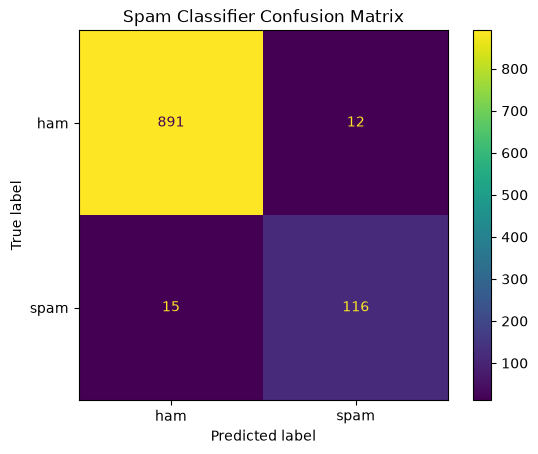

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=["ham", "spam"]
)

plt.title("Spam Classifier Confusion Matrix")
plt.savefig("images/confusion_matrix.png", bbox_inches="tight")
plt.show()

### Spam prediction logic

In [22]:
spam_index = list(model.classes_).index("spam")

spam_probabilities = model.predict_proba(X_test_tfidf)[:, spam_index]

print("First 10 spam probabilities:")

for probability in spam_probabilities[:10]:
    print(f"{probability:.2%}")

First 10 spam probabilities:
3.97%
10.34%
13.96%
8.11%
8.54%
6.87%
20.92%
2.22%
8.50%
15.98%


### Looking out for the key words of the spam

In [23]:
import numpy as np

feature_names = tfidf.get_feature_names_out()
spam_coefficients = model.coef_[0]

def get_spam_keywords(message, top_n=5):
    message_tfidf = tfidf.transform([message])

    contributions = message_tfidf.toarray()[0] * spam_coefficients

    top_indices = np.argsort(contributions)[::-1]

    keywords = []

    for index in top_indices:
        if contributions[index] > 0:
            keywords.append(feature_names[index])

        if len(keywords) == top_n:
            break

    return keywords

In [24]:
test_message = "Congratulations! You have won a free prize. Claim now!"

keywords = get_spam_keywords(test_message)

print("Spam-indicative terms:", keywords)

Spam-indicative terms: ['claim', 'free', 'prize', 'won', 'congratulations']


### Creating a function to analyse the message

In [25]:
feature_names = tfidf.get_feature_names_out()

spam_index = list(model.classes_).index("spam")

if spam_index == 1:
    spam_coefficients = model.coef_[0]
else:
    spam_coefficients = -model.coef_[0]


def analyse_message(message, top_n=5):
    message_tfidf = tfidf.transform([message])

    prediction = model.predict(message_tfidf)[0]

    probabilities = model.predict_proba(message_tfidf)[0]
    spam_probability = probabilities[spam_index]

    contributions = message_tfidf.toarray()[0] * spam_coefficients

    top_indices = np.argsort(contributions)[::-1]

    spam_terms = []

    for index in top_indices:
        if contributions[index] > 0:
            spam_terms.append(feature_names[index])

        if len(spam_terms) == top_n:
            break

    return prediction, spam_probability, spam_terms

In [26]:
message = "Congratulations! You have won a free prize. Claim now!"

prediction, probability, terms = analyse_message(message)

print("Prediction:", prediction.upper())
print(f"Spam probability: {probability:.2%}")
print("Spam-indicative terms:", terms)

Prediction: SPAM
Spam probability: 98.65%
Spam-indicative terms: ['claim', 'free', 'prize', 'won', 'congratulations']


### Importing a model to folder models

In [28]:
import joblib

joblib.dump(model, "models/spam_classifier.pkl")
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")

['models/tfidf_vectorizer.pkl']

### Checking the messages for spam

In [30]:
example_messages = [
    "Congratulations! You have won a free prize. Claim now!",
    "URGENT! You have been selected for a cash reward. Call now!",
    "You are a winner! Click here to receive your prize.",
    "FREE entry into our competition. Reply WIN to enter.",
    "Claim your exclusive reward before the offer expires!",
    "Hey, are we still meeting for coffee tomorrow?",
    "Can you pick up some milk on your way home?",
    "I'll call you when I finish work.",
    "Happy birthday! Hope you have a great day.",
    "The meeting has been moved to 2pm tomorrow."
]

results = []

for message in example_messages:
    prediction, probability, terms = analyse_message(message)

    results.append({
        "message": message,
        "prediction": prediction,
        "spam_probability": probability,
        "spam_terms": ", ".join(terms)
    })

example_results = pd.DataFrame(results)

example_results

,message,prediction,spam_probability,spam_terms
0,Congratulations! You have won a free prize. Cl...,spam,0.986506,"claim, free, prize, won, congratulations"
1,URGENT! You have been selected for a cash rewa...,spam,0.895350,"urgent, cash, reward, selected"
2,You are a winner! Click here to receive your p...,spam,0.791479,"prize, receive, winner, click"
3,FREE entry into our competition. Reply WIN to ...,spam,0.912098,"reply, free, win, entry, enter"
4,Claim your exclusive reward before the offer e...,spam,0.860949,"claim, reward, expires, offer"
5,"Hey, are we still meeting for coffee tomorrow?",ham,0.070826,
6,Can you pick up some milk on your way home?,ham,0.049834,
7,I'll call you when I finish work.,ham,0.035425,
8,Happy birthday! Hope you have a great day.,ham,0.052044,
9,The meeting has been moved to 2pm tomorrow.,ham,0.120695,


In [32]:
example_results.to_csv(
    "examples/example_predictions.csv",
    index=False
)